In [38]:
RANDOM_SEED = 2201370

In [39]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import skimage
import torch
import torch.nn as nn
import statsmodels.api as sm

from skimage.io import imread
from skimage.color import rgba2rgb, rgb2hed
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, NMF
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.metrics import normalized_mutual_info_score, mean_squared_error, r2_score
from scipy import stats
from torch.utils.data import TensorDataset, DataLoader
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from tqdm.auto import tqdm as tqdm_nb

warnings.filterwarnings('ignore')

In [40]:
df = pd.read_csv('https://warwick.ac.uk/fac/sci/dcs/teaching/material/cs909/protein_expression_data.csv')


df['specimen_id']=df.VisSpot.apply(lambda x: x.split('-')[2]) #create specimen id field
df['image_id']=df.VisSpot.apply(lambda x: x.split('-')[2])+'_'+df.id #create image id field
df = df.set_index('image_id').sort_index()
protein_names = ['SMAa', 'CD11b',
       'CD44', 'CD31', 'CDK4', 'YKL40', 'CD11c', 'HIF1a', 'CD24', 'TMEM119',
       'OLIG2', 'GFAP', 'VISTA', 'IBA1', 'CD206', 'PTEN', 'NESTIN', 'TCIRG1',
       'CD74', 'MET', 'P2RY12', 'CD163', 'S100B', 'cMYC', 'pERK', 'EGFR',
       'SOX2', 'HLADR', 'PDGFRa', 'MCT4', 'DNA1', 'DNA3', 'MHCI', 'CD68',
       'CD14', 'KI67', 'CD16', 'SOX10']
print(df)

          Unnamed: 0                VisSpot  Location_Center_Y  \
image_id                                                         
A1_0x40          412  AAGTAAGCTTCCAAAC-1-A1         764.003658   
A1_0x42         7325  GTTTGAGCGGTTATGT-1-A1         799.511111   
A1_0x44         8102  TCACTCAGCGCATTAG-1-A1         832.902467   
A1_0x46         7085  GTGCGCTTACAAATGA-1-A1         858.343544   
A1_0x48         3748  CGAAGACTGCCCGGGA-1-A1         892.179831   
...              ...                    ...                ...   
D1_9x63         3609  CCTCCCGACAATCCCT-1-D1         123.760525   
D1_9x65          172  AACACGACTGTACTGA-1-D1          29.281573   
D1_9x67         2686  CACCGCCGACCAGCGA-1-D1         938.403662   
D1_9x69         2813  CAGAGTGATTTAACGT-1-D1         844.093656   
D1_9x71         6877  GTCAGTTGTGCTCGTT-1-D1         740.107483   

          Location_Center_X      SMAa     CD11b      CD44      CD31      CDK4  \
image_id                                                    

skimage version 0.25.2


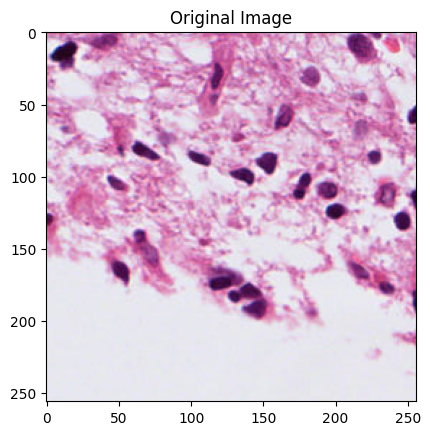

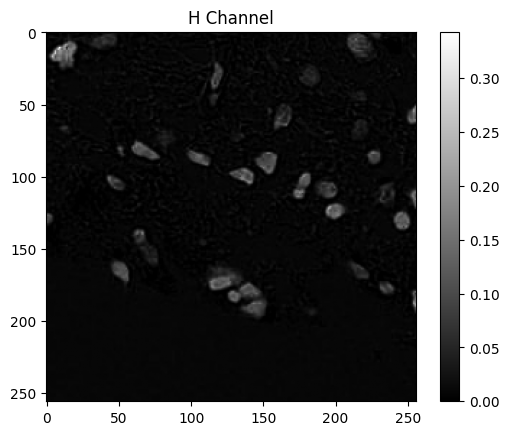

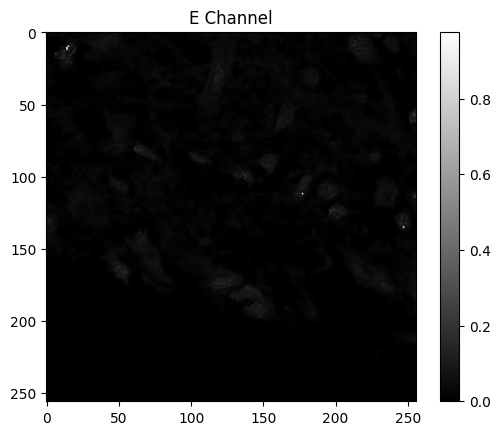

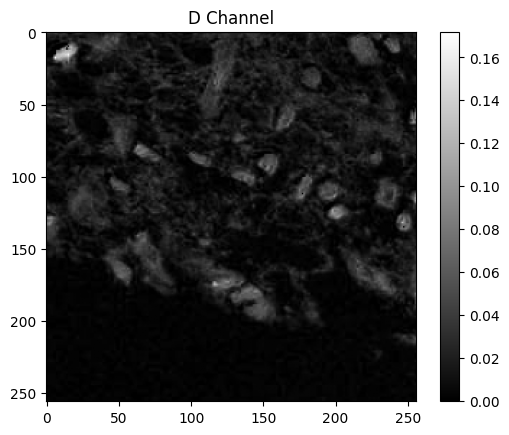

In [41]:
image_folder = 'content/patches_256/'

# Replace 'path_to_image' with the path to the image you want to display
image_path = image_folder+'A1_0x40.png'
print('skimage version',skimage.__version__)
I = rgba2rgb(imread(image_path)) #read sample RGB image
I_hed =  rgb2hed(I) #convert to HED
plt.imshow(I);plt.title('Original Image');plt.show()
I_h = I_hed[:,:,0]; plt.figure(); plt.imshow(I_h,cmap='gray');plt.colorbar();plt.title('H Channel');plt.show()
I_e = I_hed[:,:,1]; plt.figure();  plt.imshow(I_e,cmap='gray');plt.colorbar();plt.title('E Channel');plt.show()
I_d = I_hed[:,:,2]; plt.figure();  plt.imshow(I_d,cmap='gray');plt.colorbar();plt.title('D Channel');plt.show()

## Question 1: Shared Structure Between Image Space and Protein Expression Space

### (a) Construct Two Feature Spaces

#### Deliverable (i) Protein Expression Feature Matrix

Each spot is represented as a vector of 38 protein expression values, one per measured protein. Stacking all training spots gives a matrix of shape **N_train × 38**.

The preprocessing step is **z-score standardisation**, where for each protein column we subtract the training-set mean and divide by the training-set standard deviation, so every feature has zero mean and unit variance. This prevents proteins with larger absolute value ranges from dominating downstream PCA and clustering analyses.

In [42]:
# split specimens into training set (A1 B1 C1) and test set (D1)
train_df = df[df['specimen_id'].isin(['A1', 'B1', 'C1'])].copy()
test_df  = df[df['specimen_id'] == 'D1'].copy()

print(f"Protein feature matrix dimensions: train = ({len(train_df)}, {len(protein_names)}),  test = ({len(test_df)}, {len(protein_names)})")

Protein feature matrix dimensions: train = (8168, 38),  test = (1753, 38)


#### Deliverable (ii) Image Feature Representation

I represent each image using **summary statistics extracted from both the RGB and HED colour space channels**. For each of the six channels (R, G, B, H, E, D) I compute the mean and standard deviation over all pixels, giving a compact **12-dimensional feature vector** per image.

**Justification.** The RGB channels capture the raw colour distribution of the tissue patch, while the HED colour space separates the three main staining components used in histopathology. The H channel captures nuclear density, the E channel captures cytoplasm and connective tissue (stained pink), and the D channel captures DAB staining intensity directly linked to specific protein markers. Combining both spaces provides complementary information, where RGB reflects overall colour appearance while HED reflects biologically interpretable staining components, making the feature vector more informative for predicting protein expression levels. The extraction is also computationally lightweight, allowing all spots to be processed efficiently.

In [43]:
# extract mean and std of RGB and HED channels for a single image
def extract_features(image_id):
    path = image_folder + image_id + '.png'
    I = imread(path)
    if I.shape[2] == 4:                              # convert RGBA to RGB only if needed
        I = rgba2rgb(I)                              # rgba2rgb returns float64 in [0, 1]
    else:
        I = I.astype(np.float64) / 255.0             # normalise uint8 RGB to [0, 1]
    I_hed = rgb2hed(I)                               # convert RGB to HED colour space
    feats = []
    for ch in range(3):                              # RGB channels R then G then B
        feats.append(I[:, :, ch].mean())
        feats.append(I[:, :, ch].std())
    for ch in range(3):                              # HED channels H then E then D
        feats.append(I_hed[:, :, ch].mean())
        feats.append(I_hed[:, :, ch].std())
    return np.array(feats)                           # returns a 12-dimensional vector

def load_image_features(subset_df, desc=''):
    features, valid_ids = [], []
    for img_id in tqdm(subset_df.index, desc=desc):
        try:
            features.append(extract_features(img_id))
            valid_ids.append(img_id)
        except FileNotFoundError:
            pass  # skip spots whose image file is missing from disk
    return np.array(features), valid_ids

_img_cache = 'output/cache_image_features.pkl'
if os.path.exists(_img_cache):
    X_img_train_raw, train_valid_ids, X_img_test_raw, test_valid_ids = joblib.load(_img_cache)
    print("Image features loaded from cache")
else:
    X_img_train_raw, train_valid_ids = load_image_features(train_df, desc='Training set')
    print(f"{len(train_valid_ids)} / {len(train_df)} training images loaded")
    X_img_test_raw, test_valid_ids   = load_image_features(test_df,   desc='Test set')
    print(f"{len(test_valid_ids)} / {len(test_df)} test images loaded")
    joblib.dump((X_img_train_raw, train_valid_ids, X_img_test_raw, test_valid_ids), _img_cache)
    print("Image features saved to cache")

# align protein features to the same valid image ids so rows correspond
X_prot_train_raw = train_df.loc[train_valid_ids, protein_names].values
X_prot_test_raw  = test_df.loc[test_valid_ids,   protein_names].values

print(f"Protein matrix   train: {X_prot_train_raw.shape}  test: {X_prot_test_raw.shape}")
print(f"Image matrix     train: {X_img_train_raw.shape}  test: {X_img_test_raw.shape}")

Image features loaded from cache
Protein matrix   train: (8168, 38)  test: (1753, 38)
Image matrix     train: (8168, 12)  test: (1753, 12)


#### Deliverable (iii) Standardisation and Prevention of Data Leakage

Both feature spaces are standardised with `StandardScaler`. The critical rule is that **the scaler is fitted on the training set only** (A1, B1, C1), and the test set (D1) is normalised using those same training-set statistics via `.transform()`, not `.fit_transform()`.

This prevents data leakage. Fitting the scaler on the full dataset would let test-set statistics influence the normalisation, giving the model indirect access to D1 information before evaluation. Keeping D1 isolated from the fitting step ensures that performance metrics on D1 reflect genuine generalisation to unseen data.

In [44]:
# fit protein scaler on training data only then apply to both sets
prot_scaler = StandardScaler()
X_prot_train_scaled = prot_scaler.fit_transform(X_prot_train_raw)
X_prot_test_scaled  = prot_scaler.transform(X_prot_test_raw)   # no fit here

# fit image scaler on training data only then apply to both sets
img_scaler = StandardScaler()
X_img_train_scaled = img_scaler.fit_transform(X_img_train_raw)
X_img_test_scaled  = img_scaler.transform(X_img_test_raw)      # no fit here

print("Standardisation complete (scalers fitted on training set only).")
print(f"Protein features  train: {X_prot_train_scaled.shape}  test: {X_prot_test_scaled.shape}")
print(f"Image features    train: {X_img_train_scaled.shape}  test: {X_img_test_scaled.shape}")

Standardisation complete (scalers fitted on training set only).
Protein features  train: (8168, 38)  test: (1753, 38)
Image features    train: (8168, 12)  test: (1753, 12)


### (b) PCA and Intrinsic Dimensionality Analysis

#### Task (i) Scree Plot

We fit PCA separately on the protein and image training sets. The scree plot below shows the proportion of variance explained by each principal component.

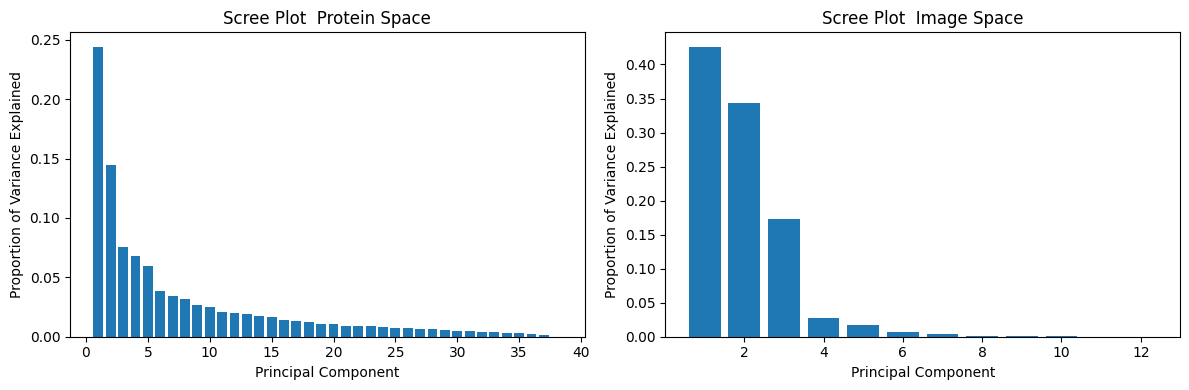

In [45]:
output_dir = 'output/'

# fit PCA on training data only for both spaces
pca_prot = PCA()
pca_prot.fit(X_prot_train_scaled)

pca_img = PCA()
pca_img.fit(X_img_train_scaled)

# task (i) scree plot  1x2 layout
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(1, len(pca_prot.explained_variance_ratio_) + 1),
            pca_prot.explained_variance_ratio_)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Scree Plot  Protein Space')

axes[1].bar(range(1, len(pca_img.explained_variance_ratio_) + 1),
            pca_img.explained_variance_ratio_)
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Proportion of Variance Explained')
axes[1].set_title('Scree Plot  Image Space')

plt.tight_layout()
plt.savefig(output_dir + 'q1b_scree_plot.png', dpi=150, bbox_inches='tight')
plt.show()

#### Task (ii) Cumulative Variance

The cumulative variance plot shows how many principal components are needed to capture a given proportion of total variance. The dashed line marks the 90% threshold.

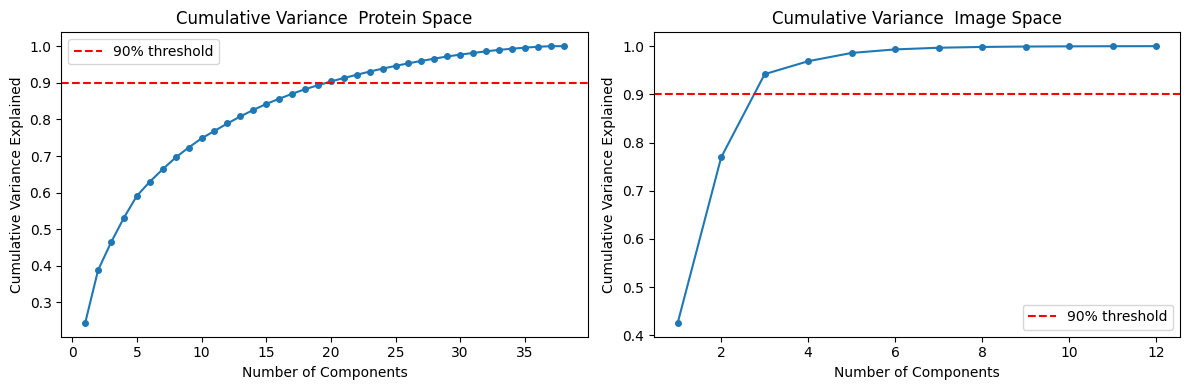

In [46]:
# task (ii) cumulative variance  1x2 layout
cumvar_prot = np.cumsum(pca_prot.explained_variance_ratio_)
cumvar_img  = np.cumsum(pca_img.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(range(1, len(cumvar_prot) + 1), cumvar_prot, marker='o', markersize=4)
axes[0].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Variance Explained')
axes[0].set_title('Cumulative Variance  Protein Space')
axes[0].legend()

axes[1].plot(range(1, len(cumvar_img) + 1), cumvar_img, marker='o', markersize=4)
axes[1].axhline(0.90, color='red', linestyle='--', label='90% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance  Image Space')
axes[1].legend()

plt.tight_layout()
plt.savefig(output_dir + 'q1b_cumulative_variance.png', dpi=150, bbox_inches='tight')
plt.show()

#### Task (iii) Components Required to Retain 90% Variance

In [47]:
# find number of components needed to retain 90% of variance in each space
n_prot_90 = int(np.argmax(cumvar_prot >= 0.90)) + 1
n_img_90  = int(np.argmax(cumvar_img  >= 0.90)) + 1

print(f"Protein space: {n_prot_90} components required to retain 90% of variance")
print(f"Image space  : {n_img_90} components required to retain 90% of variance")

# build reduced representations using the 90% threshold components
X_prot_pca = pca_prot.transform(X_prot_train_scaled)[:, :n_prot_90]
X_img_pca  = pca_img.transform(X_img_train_scaled)[:, :n_img_90]

print(f"Reduced protein PCA matrix shape: {X_prot_pca.shape}")
print(f"Reduced image PCA matrix shape  : {X_img_pca.shape}")

Protein space: 20 components required to retain 90% of variance
Image space  : 3 components required to retain 90% of variance
Reduced protein PCA matrix shape: (8168, 20)
Reduced image PCA matrix shape  : (8168, 3)


#### Task (iv) Interpretation

The image space is far more compressible than the protein space.

For the **protein space**, 20 out of 38 components are needed to retain 90% of the variance. The scree plot shows a gradual, slow decay with no sharp elbow, meaning many proteins contribute distinct variation. The cumulative curve rises steadily, reflecting that biological variation is spread broadly across the 38 protein measurements.

For the **image space**, only 3 out of 12 components are needed to retain 90% of the variance. The scree plot drops sharply after PC3 (PC1 ~42%, PC2 ~35%, PC3 ~17%), and the cumulative curve reaches the 90% threshold almost immediately.

The image space is more compressible because the 12 features (mean and std of R, G, B, H, E, D channels) are derived from the same underlying tissue patch and are highly correlated with each other. For example, the RGB channels and HED channels both reflect the same staining pattern, so much of their variance collapses into a small number of directions. In contrast, the 38 proteins measure distinct biological processes across different cell types, and while some co-expression exists, the protein variation is genuinely higher-dimensional.

This suggests that image appearance can be summarised by a very compact representation (3 dimensions), whereas protein expression profiles carry richer, more independent biological signals that require more dimensions to describe adequately.

### (c) Clustering in PCA Space

#### Task (i) K-means Clustering

We use K=4 because the dataset contains exactly four specimens (A1, B1, C1, D1), which makes the cluster labels directly comparable to specimen identity in Q1(d). All spots (train and test) are projected through the training-fitted PCA before clustering. This does not refit the PCA and introduces no data leakage.

In [48]:
# project all spots (train and test) through the training-fitted PCA
# transform only, no refit, so D1 statistics do not influence the PCA
X_prot_all_pca = pca_prot.transform(
    np.vstack([X_prot_train_scaled, X_prot_test_scaled]))[:, :n_prot_90]
X_img_all_pca  = pca_img.transform(
    np.vstack([X_img_train_scaled, X_img_test_scaled]))[:, :n_img_90]

# collect specimen labels for all spots in the same row order
specimen_all = np.concatenate([
    train_df.loc[train_valid_ids, 'specimen_id'].values,
    test_df.loc[test_valid_ids,   'specimen_id'].values
])

_km_cache = 'output/cache_kmeans.pkl'
if os.path.exists(_km_cache):
    labels_prot, labels_img = joblib.load(_km_cache)
    print("K-means labels loaded from cache")
else:
    kmeans_prot = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    labels_prot = kmeans_prot.fit_predict(X_prot_all_pca)

    kmeans_img = KMeans(n_clusters=4, random_state=RANDOM_SEED, n_init=10)
    labels_img = kmeans_img.fit_predict(X_img_all_pca)

    joblib.dump((labels_prot, labels_img), _km_cache)
    print("K-means fitted and cached")

print(f"Protein space cluster sizes: {np.bincount(labels_prot)}")
print(f"Image space cluster sizes  : {np.bincount(labels_img)}")

K-means labels loaded from cache
Protein space cluster sizes: [ 390 4967  327 4237]
Image space cluster sizes  : [4287 1806 3138  690]


#### Task (ii) 2D PCA Scatter Plots Coloured by Cluster

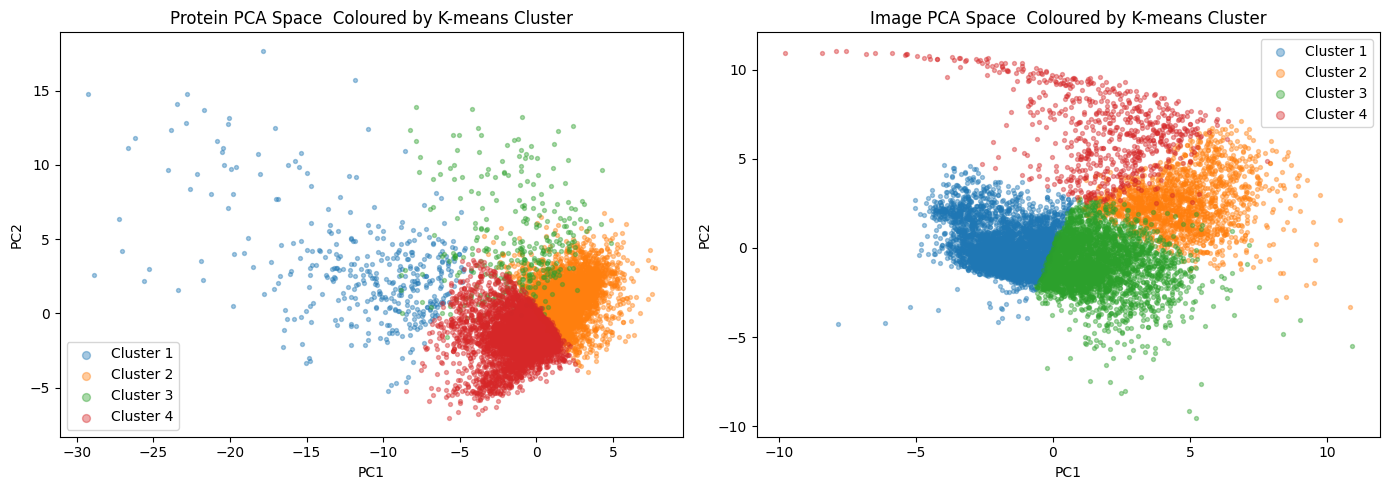

In [49]:
colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for k in range(4):
    mask = labels_prot == k
    axes[0].scatter(X_prot_all_pca[mask, 0], X_prot_all_pca[mask, 1],
                    c=colors[k], label=f'Cluster {k+1}', alpha=0.4, s=8)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].set_title('Protein PCA Space  Coloured by K-means Cluster')
axes[0].legend(markerscale=2)

for k in range(4):
    mask = labels_img == k
    axes[1].scatter(X_img_all_pca[mask, 0], X_img_all_pca[mask, 1],
                    c=colors[k], label=f'Cluster {k+1}', alpha=0.4, s=8)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].set_title('Image PCA Space  Coloured by K-means Cluster')
axes[1].legend(markerscale=2)

plt.tight_layout()
plt.savefig('output/q1c_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#### Comment on Cluster Structure

The two spaces show markedly different cluster structures.

In the **protein PCA space**, Clusters 2 and 4 are both large (4967 and 4237 spots respectively) and heavily overlap in the PC1-PC2 projection, while Clusters 1 and 3 are much smaller (390 and 327 spots) and sit further out in the negative PC1 region. The poor visual separation in 2D is consistent with the earlier finding that 20 principal components are needed to retain 90% of the variance, meaning the cluster structure is spread across many dimensions. This pattern suggests the protein clusters are **potentially biological** rather than specimen-driven, as spots group according to multi-dimensional expression patterns that cut across specimen boundaries.

In the **image PCA space**, the four clusters form distinct wedge-shaped sectors radiating from a common origin, producing much less overlap. Since the image features are colour summary statistics, this radial pattern most likely reflects overall colour differences between specimens rather than any finer-grained structure within specimens. The image space clusters therefore appear **specimen-driven**, consistent with between-specimen staining variation dominating the image feature space.

### (d) Association Between Clusters and Specimen Structure

#### Task (i) Image vs Protein Cluster Agreement

In [50]:
# compute NMI between image-space and protein-space cluster labels
nmi_img_prot = normalized_mutual_info_score(labels_img, labels_prot)
print(f"NMI(image clusters, protein clusters) = {nmi_img_prot:.4f}")

NMI(image clusters, protein clusters) = 0.0912


The NMI value of 0.0912 indicates very weak agreement between the image-space and protein-space clusterings, meaning the two spaces partition the spots in largely independent ways and share little common structure at the cluster level.

#### Task (ii) Cluster vs Specimen Association

In [51]:
# compute NMI between each clustering and specimen identity
nmi_img_s  = normalized_mutual_info_score(labels_img,  specimen_all)
nmi_prot_s = normalized_mutual_info_score(labels_prot, specimen_all)

# display all three NMI values as a summary table
nmi_table = pd.DataFrame(
    {'NMI': [nmi_img_prot, nmi_img_s, nmi_prot_s]},
    index=['Image clusters vs Protein clusters',
           'Image clusters vs Specimen NMI(c^img,s)',
           'Protein clusters vs Specimen NMI(c^prot,s)']
)
display(nmi_table.round(4))

,NMI
Image clusters vs Protein clusters,0.0912
"Image clusters vs Specimen NMI(c^img,s)",0.3010
"Protein clusters vs Specimen NMI(c^prot,s)",0.0100


The image clustering is more specimen-driven. Its NMI with specimen identity is 0.3010, which is substantially higher than the corresponding value of 0.0100 for the protein clustering. This confirms that image clusters are meaningfully aligned with which specimen a spot comes from, while protein clusters are almost entirely independent of specimen identity.

#### Task (iii) Interpretation and Reasoning

The NMI values show that the image and protein clusters are more aligned with specimen identity than with each other in the image space, but the reverse is true for the protein space.

For the image clustering, the NMI with specimen (0.3010) is considerably higher than its NMI with protein clusters (0.0912). This suggests that image features primarily reflect between-specimen differences such as staining intensity variation, which is a form of domain shift rather than shared biological structure.

For the protein clustering, the NMI with specimen (0.0100) is near zero, indicating that protein-based groupings are not driven by which specimen a spot originates from. The protein clusters therefore capture variation that is consistent across specimens, which is more consistent with underlying biological structure.

Taken together, the low NMI between the two clusterings (0.0912) combined with the contrast between their specimen associations suggests that the image and protein spaces do not share substantial common structure at the clustering level. The image space is dominated by a domain shift effect, while the protein space reflects a higher-dimensional biological signal that is largely specimen-independent.

### Bonus: Discovery of Latent Topics via NMF

Non-negative Matrix Factorization (NMF) decomposes a data matrix into two non-negative factors. The first is a topic activation matrix W (one row per spot, one column per topic) and the second is a topic loading matrix H (one row per topic, one column per feature). Each topic is an additive combination of features, making the results directly interpretable as latent patterns.

To jointly model both spaces, the protein features (38 dimensions) and image features (12 dimensions) are concatenated into a single 50-dimensional matrix. NMF then finds topics that simultaneously explain variation in both protein expression and image appearance. Because NMF requires non-negative input, each feature column is shifted by subtracting its minimum value before fitting. K=5 topics is chosen as a compact yet expressive number of factors for a 50-dimensional space, balancing interpretability against reconstruction quality.

In [52]:
# concatenate protein and image features for training set
X_joint = np.hstack([X_prot_train_scaled, X_img_train_scaled])

# NMF requires non-negative input so shift each column by its minimum
X_joint_nn = X_joint - X_joint.min(axis=0)

K = 5
_nmf_cache = 'output/cache_nmf.pkl'
if os.path.exists(_nmf_cache):
    nmf_model, W, H = joblib.load(_nmf_cache)
    print("NMF loaded from cache")
else:
    nmf_model = NMF(n_components=K, random_state=RANDOM_SEED, max_iter=500)
    W = nmf_model.fit_transform(X_joint_nn)  # topic activations per spot (N_train x K)
    H = nmf_model.components_               # topic loadings over features (K x 50)
    joblib.dump((nmf_model, W, H), _nmf_cache)
    print("NMF fitted and cached")

print(f"NMF reconstruction error: {nmf_model.reconstruction_err_:.4f}")
print(f"Topic activation matrix W: {W.shape}")
print(f"Topic loading matrix H:    {H.shape}")

NMF loaded from cache
NMF reconstruction error: 434.7695
Topic activation matrix W: (8168, 5)
Topic loading matrix H:    (5, 50)


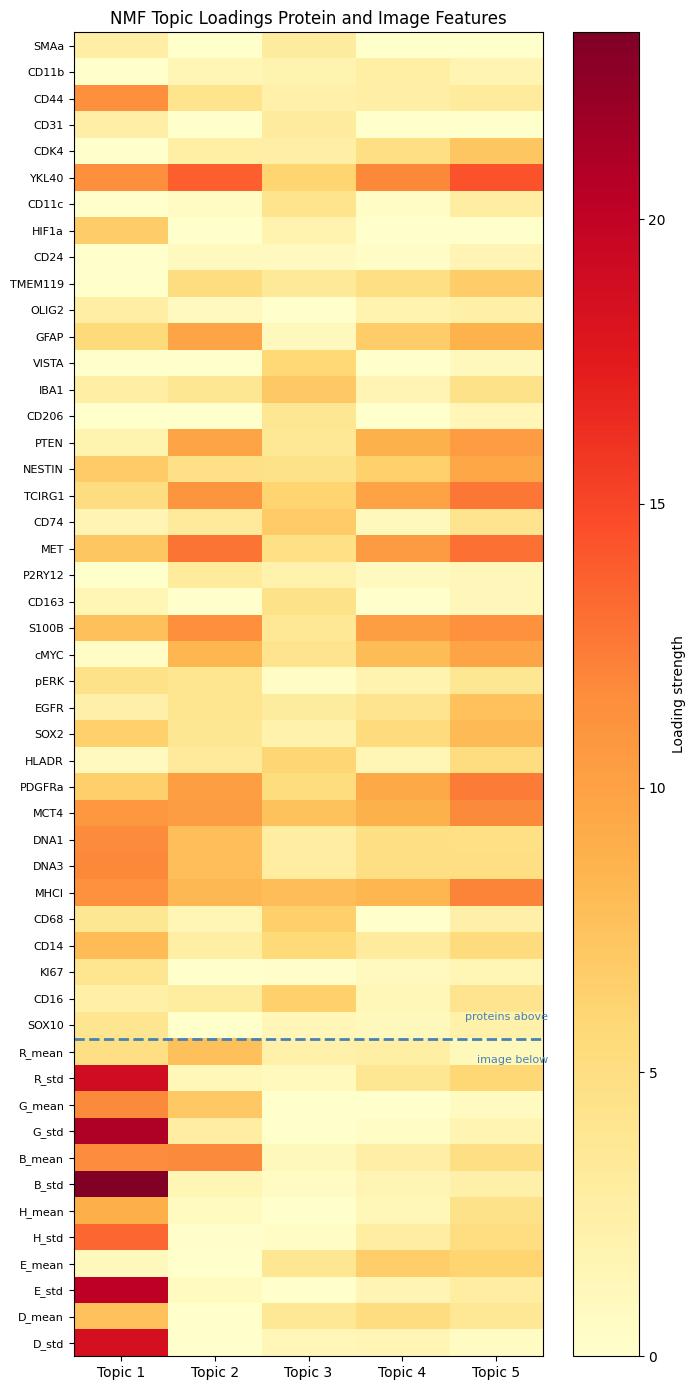

In [53]:
# feature names in the same order as the concatenated matrix
image_feat_names = ['R_mean','R_std','G_mean','G_std','B_mean','B_std',
                    'H_mean','H_std','E_mean','E_std','D_mean','D_std']
all_feat_names = protein_names + image_feat_names
topic_labels = [f'Topic {k+1}' for k in range(K)]

# heatmap of topic loadings: rows = features, columns = topics
fig, ax = plt.subplots(figsize=(7, 14))
im = ax.imshow(H.T, aspect='auto', cmap='YlOrRd')
ax.set_xticks(range(K))
ax.set_xticklabels(topic_labels, fontsize=10)
ax.set_yticks(range(len(all_feat_names)))
ax.set_yticklabels(all_feat_names, fontsize=8)

# separator line between protein features and image features
ax.axhline(37.5, color='steelblue', linewidth=2, linestyle='--')
ax.text(K - 0.45, 36.5, 'proteins above', va='top', ha='right', fontsize=8, color='steelblue')
ax.text(K - 0.45, 38.5, 'image below',    va='bottom', ha='right', fontsize=8, color='steelblue')

plt.colorbar(im, ax=ax, label='Loading strength')
ax.set_title('NMF Topic Loadings Protein and Image Features')
plt.tight_layout()
plt.savefig('output/bonus_nmf_loadings.png', dpi=150, bbox_inches='tight')
plt.show()

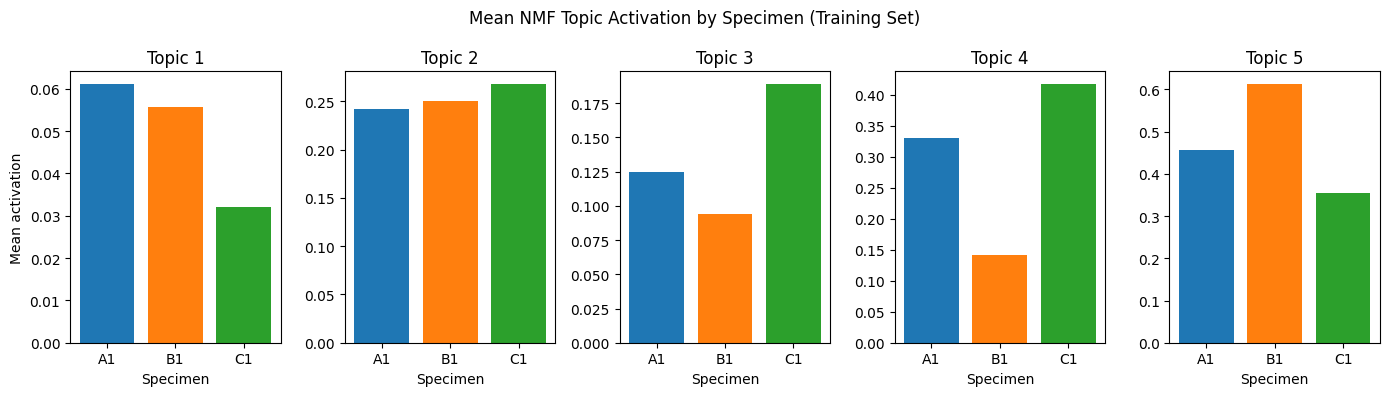

In [54]:
# mean topic activation per specimen for training spots
specimen_train_labels = train_df.loc[train_valid_ids, 'specimen_id'].values
specimens = ['A1', 'B1', 'C1']
colors = ['tab:blue', 'tab:orange', 'tab:green']

fig, axes = plt.subplots(1, K, figsize=(14, 4), sharey=False)
for k in range(K):
    means = [W[specimen_train_labels == s, k].mean() for s in specimens]
    axes[k].bar(specimens, means, color=colors)
    axes[k].set_title(f'Topic {k+1}')
    axes[k].set_xlabel('Specimen')
    if k == 0:
        axes[k].set_ylabel('Mean activation')

plt.suptitle('Mean NMF Topic Activation by Specimen (Training Set)')
plt.tight_layout()
plt.savefig('output/bonus_nmf_specimen_activation.png', dpi=150, bbox_inches='tight')
plt.show()

**Topic 1** is the only topic that loads strongly on image features, with R_std, G_std, B_std, E_std and D_std all showing the highest loading strengths in the heatmap. It also picks up modest contributions from a few proteins (YKL40, CD44, HIF1a). Intuitively, this topic seems to capture how "spread out" the colours are in a patch, where spots with uneven staining tend to activate it more. Its mean activation is reasonably balanced across A1, B1 and C1 (0.061, 0.056, 0.032), suggesting it is not specific to one specimen. This makes Topic 1 the closest thing the model finds to a shared latent factor that bridges image appearance and protein expression.

**Topic 2** loads broadly across many proteins including YKL40, MET, GFAP, NESTIN, TCIRG1 and PDGFRa, with near-zero image feature loadings. Its specimen activations are the most evenly distributed of the five (A1 0.242, B1 0.250, C1 0.268). A topic that activates at similar levels across all three specimens is less likely to be driven by staining differences between batches and more likely to reflect a genuine pattern in protein co-expression that exists regardless of which sample the spot came from. Topic 2 is therefore the strongest candidate for a biologically meaningful latent factor.

**Topics 3, 4 and 5** are also protein-dominated with minimal image coupling, but their specimen activations are noticeably uneven. Topic 3 is much stronger in C1 (0.189) than in B1 (0.094), Topic 4 shows a low B1 activation (0.142) compared to A1 (0.331) and C1 (0.417), and Topic 5 peaks in B1 (0.612) while being weaker in A1 (0.455) and C1 (0.354). These imbalances suggest that Topics 3 to 5 are picking up protein patterns that are at least partly specific to individual specimens rather than being consistently shared across all of them.

Overall, the NMF decomposition separates image variation from protein variation quite cleanly. Only Topic 1 meaningfully bridges both modalities, while Topics 2 to 5 are almost entirely protein-driven. The even specimen activations in Topics 1 and 2 suggest some latent structure is genuinely shared across specimens, while the imbalances in Topics 3 to 5 show that specimen identity still leaves a footprint on protein variation even after factorisation.

## Question 2: Predicting Protein Expression from Image Features

### (a) Association Between H-channel Intensity and cMYC Expression

For each spot we define:

- **H_i** = mean H-channel intensity of the image patch (already extracted in Q1(a) as column index 6 of `X_img_train_raw`)
- **y_i** = cMYC protein expression value (column `cMYC` of the training protein matrix)

All analysis in this section uses the training set (A1, B1, C1) with raw, unscaled values so that the regression coefficients remain interpretable in their original units.

In [55]:
# extract H-channel mean and cMYC expression from training data (raw, unscaled)
cmyc_idx = protein_names.index('cMYC')
H_train = X_img_train_raw[:, 6]        # H-channel mean intensity
y_train = X_prot_train_raw[:, cmyc_idx] # cMYC expression

#### 1. Scatter Plot of H-channel Intensity vs cMYC Expression

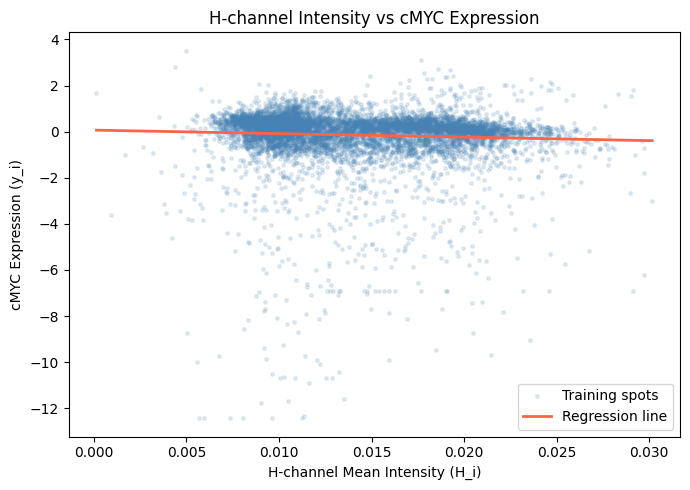

In [56]:
# fit a line to overlay on the scatter plot
m, b = np.polyfit(H_train, y_train, 1)
x_line = np.linspace(H_train.min(), H_train.max(), 200)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(H_train, y_train, alpha=0.15, s=6, color='steelblue', label='Training spots')
ax.plot(x_line, m * x_line + b, color='tomato', linewidth=2, label='Regression line')
ax.set_xlabel('H-channel Mean Intensity (H_i)')
ax.set_ylabel('cMYC Expression (y_i)')
ax.set_title('H-channel Intensity vs cMYC Expression')
ax.legend()
plt.tight_layout()
plt.savefig('output/q2a_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

The scatter plot shows a diffuse point cloud with no clear visual trend. Points are spread widely around the regression line, and the line has only a slight negative slope. A small number of spots with extreme cMYC values extend the vertical range, which may distort a linear fit.

#### 2. Pearson and Spearman Correlation

In [57]:
pearson_r,  pearson_p  = stats.pearsonr(H_train, y_train)
spearman_r, spearman_p = stats.spearmanr(H_train, y_train)

print(f"Pearson  r = {pearson_r:.4f}   p = {pearson_p:.4e}")
print(f"Spearman r = {spearman_r:.4f}   p = {spearman_p:.4e}")

Pearson  r = -0.0561   p = 3.9811e-07
Spearman r = -0.1751   p = 3.1176e-57


The Pearson correlation is r = -0.0561 (p = 3.98e-07) and the Spearman correlation is rho = -0.1751 (p = 3.12e-57). Both are statistically significant, indicating a genuine negative association between H-channel intensity and cMYC expression. The magnitude of both values is small, so the relationship is weak. The Spearman value is notably larger in absolute terms than the Pearson value, which suggests the relationship is non-linear and that outliers are reducing the Pearson estimate.

#### 3. Simple Linear Regression

In [58]:
# fit y_i ~ beta_0 + beta_1 * H_i + error_i
X_ols = sm.add_constant(H_train)
ols_model = sm.OLS(y_train, X_ols).fit()

beta_0 = ols_model.params[0]
beta_1 = ols_model.params[1]
r_squared = ols_model.rsquared
p_beta1 = ols_model.pvalues[1]

print(f"beta_0 (intercept) = {beta_0:.4f}")
print(f"beta_1             = {beta_1:.4f}")
print(f"R²                 = {r_squared:.4f}")
print(f"p-value (beta_1)   = {p_beta1:.4e}")

beta_0 (intercept) = 0.0659
beta_1             = -15.2071
R²                 = 0.0031
p-value (beta_1)   = 3.9811e-07


The fitted model is y-hat = 0.0659 - 15.21 * H_i. The slope beta_1 = -15.21 is statistically significant (p = 3.98e-07, well below 0.05), so we reject the null hypothesis of no linear association. The association is **statistically significant**. However, R² = 0.0031 means H-channel intensity explains only 0.31% of the variance in cMYC expression. The association is real but very weak in practical terms.

#### Bonus Question

To test whether the H-cMYC association reflects a genuine within-specimen relationship rather than a between-specimen batch effect, we add specimen identity as a set of dummy variables to the regression model.

The extended model is:

y_i ~ β₀ + β₁·H_i + β₂·Spec_B1 + β₃·Spec_C1

where Spec_B1 and Spec_C1 are binary indicators for specimens B1 and C1 (A1 is the reference). If β₁ remains similar in magnitude and significance after adding these controls, the H-cMYC association holds within specimens and is not merely a specimen-level artifact. If β₁ drops substantially or becomes non-significant, the association was largely driven by between-specimen differences.

In [59]:
# build a DataFrame with H, cMYC and specimen dummies
specimen_train_arr = train_df.loc[train_valid_ids, 'specimen_id'].values
bonus_df = pd.DataFrame({
    'H':    H_train,
    'cMYC': y_train,
    'Spec_B1': (specimen_train_arr == 'B1').astype(int),
    'Spec_C1': (specimen_train_arr == 'C1').astype(int),
})

X_bonus = sm.add_constant(bonus_df[['H', 'Spec_B1', 'Spec_C1']])
bonus_model = sm.OLS(bonus_df['cMYC'], X_bonus).fit()

print(bonus_model.summary2().tables[1][['Coef.','P>|t|','[0.025','0.975]']])
print(f"R² with specimen controls: {bonus_model.rsquared:.4f}")
print(f"R² without controls:        {r_squared:.4f}")

             Coef.     P>|t|     [0.025    0.975]
const     0.013021  0.835760  -0.110094  0.136136
H       -12.811388  0.000630 -20.155064 -5.467711
Spec_B1  -0.003431  0.940868  -0.094104  0.087242
Spec_C1   0.039067  0.252949  -0.027916  0.106051
R² with specimen controls: 0.0033
R² without controls:        0.0031


After controlling for specimen identity, the coefficient for H remains negative and statistically significant (beta_1 = -12.81, p = 0.000630). The specimen dummy variables are both far from significant (Spec_B1 p = 0.94, Spec_C1 p = 0.25), and the R² increases only marginally from 0.0031 to 0.0033. This means that specimen identity contributes essentially nothing to explaining cMYC expression once H is already in the model.

The conclusion is that the H-cMYC association is **robust to specimen-level differences** and is not merely a batch effect. The relationship holds within each specimen, which makes it a genuine statistical signal rather than an artifact of between-specimen staining variation. That said, the overall explanatory power remains very low regardless of whether specimen controls are included.

### (b) Predicting CDK4 Expression from Image Features

#### (i) Feature Design and Justification

The same 12-dimensional feature vectors from Q1 are reused here. They consist of the mean and standard deviation of each of the three RGB channels and three HED channels, giving 12 features in total.

The H channel was shown in part (a) to have a statistically significant association with cMYC expression, so it is likely to carry useful signal for other proteins as well. Including its standard deviation captures spatial variation in staining intensity across the patch, which may reflect tissue heterogeneity related to protein expression.

The RGB channels provide complementary information about overall image colour and brightness. Using all 12 features together gives the model a broader set of image statistics to work with, without needing to select features manually in advance.

#### (ii) Regression Modelling and Evaluation

A **Random Forest** regressor is used here. Compared to SVR and MLP, Random Forest is robust to the scale of input features without requiring normalisation, handles non-linear relationships naturally through ensemble tree splitting, and is less sensitive to hyperparameter choices. Hyperparameters are tuned via 5-fold cross-validation GridSearchCV on the training set (A1, B1, C1).

In [60]:
# extract CDK4 expression as the regression target
cdk4_idx = protein_names.index('CDK4')
y_cdk4_train = X_prot_train_raw[:, cdk4_idx]
y_cdk4_test  = X_prot_test_raw[:,  cdk4_idx]

In [61]:
_rf_cache = 'output/cache_rf_cdk4.pkl'

if os.path.exists(_rf_cache):
    rf_best, y_cdk4_pred = joblib.load(_rf_cache)
    print("Random Forest loaded from cache")
else:
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth':    [5, 10, None],
        'min_samples_leaf': [1, 5, 10],
    }
    rf = RandomForestRegressor(random_state=RANDOM_SEED, n_jobs=-1)
    gs = GridSearchCV(rf, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
    gs.fit(X_img_train_scaled, y_cdk4_train)

    rf_best = gs.best_estimator_
    y_cdk4_pred = rf_best.predict(X_img_test_scaled)

    joblib.dump((rf_best, y_cdk4_pred), _rf_cache)
    print("Random Forest fitted and cached")

print(f"Best params: {rf_best.get_params()}")

Random Forest loaded from cache
Best params: {'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 1.0, 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 10, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 2201370, 'verbose': 0, 'warm_start': False}


,Value
Metric,
RMSE,1.0366
Pearson r,0.6017
Spearman r,0.6753
R2,0.1259


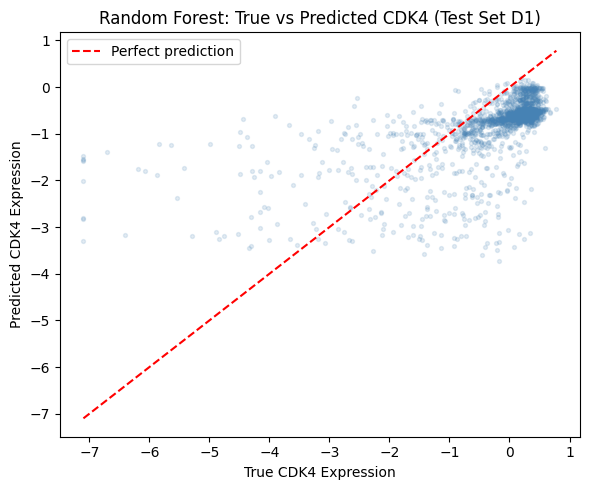

In [62]:
# performance metrics on test set (D1)
rmse        = np.sqrt(mean_squared_error(y_cdk4_test, y_cdk4_pred))
pearson_r,  _ = stats.pearsonr(y_cdk4_test,  y_cdk4_pred)
spearman_r, _ = stats.spearmanr(y_cdk4_test, y_cdk4_pred)
ss_res = np.sum((y_cdk4_test - y_cdk4_pred) ** 2)
ss_tot = np.sum((y_cdk4_test - y_cdk4_test.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'Pearson r', 'Spearman r', 'R2'],
    'Value':  [round(rmse, 4), round(pearson_r, 4), round(spearman_r, 4), round(r2, 4)]
}).set_index('Metric')
display(metrics_df)

# scatter plot true vs predicted on test set
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(y_cdk4_test, y_cdk4_pred, alpha=0.15, s=8, color='steelblue')
lims = [min(y_cdk4_test.min(), y_cdk4_pred.min()),
        max(y_cdk4_test.max(), y_cdk4_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('True CDK4 Expression')
ax.set_ylabel('Predicted CDK4 Expression')
ax.set_title('Random Forest: True vs Predicted CDK4 (Test Set D1)')
ax.legend()
plt.tight_layout()
plt.savefig('output/q2b_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

#### (iii) Interpretation

The Random Forest model achieves a Pearson correlation of 0.6017, Spearman correlation of 0.6753, R² of 0.1259 and RMSE of 1.0366 on the held-out test set D1. The moderate correlations indicate that the model captures a real relationship between image appearance and CDK4 expression, but the R² of 0.1259 means that only about 13% of the variance in CDK4 is explained by the image features. Prediction is therefore possible but remains limited in precision.

The Spearman correlation (0.6753) is noticeably higher in absolute terms than the Pearson correlation (0.6017). This suggests the relationship is partly non-linear or affected by outliers, which is one reason a non-linear model like Random Forest performs better than simple linear regression.

These results are broadly consistent with the Q2(a) findings. In part (a), a single H-channel feature explained only 0.31% of cMYC variance under linear regression. The larger R² here (0.126) comes from using all 12 image features rather than just the H-channel mean, and from using a non-linear model that can exploit feature interactions. Even so, the absolute R² remains modest, which aligns with the Q1 finding that image and protein spaces have very different cluster structures (NMI = 0.0912) and that image clustering is largely specimen-driven rather than reflecting the biological variation captured by protein expression. 

In short, the model does learn something useful, but image colour statistics simply do not contain enough information to predict protein expression with high accuracy.

## Q3 Predicting Protein Expression from Images with Neural Networks

**Option A**:This question uses a convolutional neural network (CNN) to predict protein expression from tissue images. A ResNet-18 backbone (ImageNet-pretrained, backbone frozen) with a small regression head added on top is selected.

The frozen backbone provides rich feature representations without the risk of overfitting on a small dataset, while training only the head keeps computation manageable.

In [63]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
BATCH  = 256    # large batch is fine -- no image I/O per step
EPOCHS = 100    # affordable because training is on cached feature vectors
LR     = 1e-3
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

Using device: cuda


In [64]:
# ── ResNet-18 local weights ───────────────────────────────────────────────────
RESNET_LOCAL_WEIGHTS = 'output/resnet18_imagenet.pth'
if not os.path.exists(RESNET_LOCAL_WEIGHTS):
    print('Downloading ResNet-18 ImageNet weights (first time only)...')
    _tmp = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    torch.save(_tmp.state_dict(), RESNET_LOCAL_WEIGHTS)
    del _tmp
    print(f'Saved to {RESNET_LOCAL_WEIGHTS}')
else:
    print(f'ResNet-18 weights found at {RESNET_LOCAL_WEIGHTS}')

# ── Image transform (ImageNet normalisation) ─────────────────────────────────
img_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# ── Feature extraction: run all images through frozen backbone once ───────────
def extract_resnet_features(image_ids, image_folder, backbone, batch_size=64):
    """Pass images through a frozen CNN backbone; return (N, D) feature matrix."""
    backbone.eval()
    backbone.to(device)
    all_feats = []
    pbar = tqdm_nb(range(0, len(image_ids), batch_size),
                   desc='Extracting ResNet features', unit='batch')
    for start in pbar:
        batch_ids = image_ids[start:start + batch_size]
        imgs = []
        for img_id in batch_ids:
            img = Image.open(
                os.path.join(image_folder, img_id + '.png')
            ).convert('RGB')
            imgs.append(img_transform(img))
        batch_t = torch.stack(imgs).to(device)
        with torch.no_grad():
            feats = backbone(batch_t).squeeze(-1).squeeze(-1)  # (B, 512)
        all_feats.append(feats.cpu().numpy())
    return np.concatenate(all_feats, axis=0)

# build frozen backbone (strip the classification fc head)
_resnet_full = models.resnet18(weights=None)
_resnet_full.load_state_dict(
    torch.load(RESNET_LOCAL_WEIGHTS, map_location='cpu')
)
backbone_only = nn.Sequential(*list(_resnet_full.children())[:-1])
for p in backbone_only.parameters():
    p.requires_grad = False
del _resnet_full

# extract or load cached features
FEAT_CACHE = 'output/cache_resnet_features.pkl'
all_ids = df.index.tolist()

if os.path.exists(FEAT_CACHE):
    feat_dict = joblib.load(FEAT_CACHE)
    print(f'Loaded ResNet features from cache: {len(feat_dict)} images')
else:
    print(f'Extracting features for {len(all_ids)} images...')
    feat_matrix = extract_resnet_features(
        all_ids, image_folder, backbone_only, batch_size=64
    )
    feat_dict = {img_id: feat_matrix[i] for i, img_id in enumerate(all_ids)}
    joblib.dump(feat_dict, FEAT_CACHE)
    print(f'Saved to {FEAT_CACHE}')

# align with train / test split
X_feat_train = np.array(
    [feat_dict[i] for i in train_df.index], dtype=np.float32
)
X_feat_test = np.array(
    [feat_dict[i] for i in test_df.index], dtype=np.float32
)
print(f'Feature matrices: train={X_feat_train.shape}, test={X_feat_test.shape}')

ResNet-18 weights found at output/resnet18_imagenet.pth
Loaded ResNet features from cache: 9921 images
Feature matrices: train=(8168, 512), test=(1753, 512)


In [65]:
class FeatureMLP(nn.Module):
    """MLP regression head trained on precomputed ResNet-18 feature vectors."""
    def __init__(self, in_dim=512, hidden=256, out_dim=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        return self.net(x)


class FeatureMLPWithCoords(nn.Module):
    """Same MLP but accepts [ResNet features | normalised x, y] as input."""
    def __init__(self, feat_dim=512, coord_dim=2, hidden=256, out_dim=1, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(feat_dim + coord_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 64),
            nn.ReLU(),
            nn.Linear(64, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [66]:
def fit_mlp(model, X_tr, y_tr, X_va, y_va, epochs, lr, cache_path):
    """Train FeatureMLP on pre-extracted NumPy feature arrays."""
    history_path = cache_path.replace('.pt', '_history.npz')

    if os.path.exists(cache_path):
        print(f'Loading cached model from {cache_path}')
        model.load_state_dict(torch.load(cache_path, map_location=device))
        model.to(device)
        # restore training history if saved alongside the model
        if os.path.exists(history_path):
            h = np.load(history_path)
            return model, h['train'].tolist(), h['val'].tolist()
        return model, None, None

    T = lambda a: torch.tensor(np.array(a), dtype=torch.float32)
    ds_tr = TensorDataset(T(X_tr), T(y_tr))
    ds_va = TensorDataset(T(X_va), T(y_va))
    ld_tr = DataLoader(ds_tr, batch_size=BATCH, shuffle=True)
    ld_va = DataLoader(ds_va, batch_size=BATCH, shuffle=False)

    model.to(device)
    criterion = nn.MSELoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimiser, T_max=epochs, eta_min=1e-6
    )
    is_multi = (y_tr.ndim == 2)

    train_losses, val_losses = [], []
    pbar = tqdm_nb(range(epochs), desc='Training', unit='epoch')
    for _ in pbar:
        model.train()
        tl = 0.0
        for xb, yb in ld_tr:
            xb, yb = xb.to(device), yb.to(device)
            optimiser.zero_grad()
            out = model(xb) if is_multi else model(xb).squeeze(-1)
            loss = criterion(out, yb)
            loss.backward()
            optimiser.step()
            tl += loss.item() * len(xb)
        tl /= len(ds_tr)

        model.eval()
        vl = 0.0
        with torch.no_grad():
            for xb, yb in ld_va:
                xb, yb = xb.to(device), yb.to(device)
                out = model(xb) if is_multi else model(xb).squeeze(-1)
                vl += criterion(out, yb).item() * len(xb)
        vl /= len(ds_va)

        scheduler.step()
        train_losses.append(tl)
        val_losses.append(vl)
        pbar.set_postfix(
            train=f'{tl:.4f}', val=f'{vl:.4f}',
            lr=f'{optimiser.param_groups[0]["lr"]:.1e}'
        )

    torch.save(model.state_dict(), cache_path)
    # save history so the training curve survives future cache loads
    np.savez(history_path, train=train_losses, val=val_losses)
    return model, train_losses, val_losses


def predict_mlp(model, X):
    """Run inference on a NumPy feature matrix; returns NumPy predictions."""
    model.eval()
    model.to(device)
    with torch.no_grad():
        out = model(
            torch.tensor(X, dtype=torch.float32).to(device)
        ).cpu().numpy()
    return out

### (a) Single-target neural network for cMYC prediction

#### (i) Model Design and Training

The model uses **transfer learning**: a ResNet-18 backbone (pretrained on ImageNet) acts as a fixed feature extractor, producing a 512-dimensional vector per image patch. A lightweight MLP regression head is then trained on these precomputed vectors to predict cMYC expression.

This two-stage design is chosen for three reasons. First, ResNet-18 features generalise well from natural images to histology because low- and mid-level visual patterns (edges, textures, colour gradients) are shared across domains. Second, keeping the backbone frozen avoids overfitting on the limited number of training spots and removes the risk of the backbone adapting to specimen-specific artefacts. Third, precomputing the features once makes training fast and reproducible, allowing proper hyperparameter search with 100 epochs.

The MLP head has the structure: **FC(512 → 256) → BatchNorm → ReLU → Dropout(0.3) → FC(256 → 64) → ReLU → FC(64 → 1)**. The loss function is **MSE**, which is standard for continuous regression and penalises large prediction errors quadratically. The optimiser is **Adam** with weight decay 1e-4 and a cosine-annealing learning rate schedule (**initial LR = 1e-3, final LR = 1e-6 over 100 epochs**).

The hyperparameter choices are made as follows. A hidden size of 256 is large enough to capture non-linear patterns in the 512-dim feature space but small enough to avoid overfitting given around 8000 training samples. Dropout(0.3) is added as a regulariser to reduce reliance on individual features. Adam is preferred over SGD because it adapts the learning rate per parameter and converges reliably without extensive tuning. The initial LR of 1e-3 is a standard starting point for Adam, and cosine annealing gradually reduces it to 1e-6 so the model can fine-tune without oscillating near the end of training. Weight decay 1e-4 provides mild L2 regularisation. 100 epochs is sufficient for the loss to plateau given the small model size and precomputed inputs.

In [76]:
# cMYC labels: z-scored on training set only
cmyc_train_raw = train_df['cMYC'].values.reshape(-1, 1)
cmyc_test_raw  = test_df['cMYC'].values.reshape(-1, 1)
scaler_cmyc    = StandardScaler().fit(cmyc_train_raw)
y_train_cmyc   = scaler_cmyc.transform(cmyc_train_raw).ravel().astype(np.float32)
y_test_cmyc    = scaler_cmyc.transform(cmyc_test_raw).ravel().astype(np.float32)

torch.manual_seed(RANDOM_SEED)
cache_cmyc = 'output/cache_mlp_cmyc.pt'
model_cmyc = FeatureMLP(in_dim=512, hidden=256, out_dim=1)
model_cmyc, tl_cmyc, vl_cmyc = fit_mlp(
    model_cmyc,
    X_feat_train, y_train_cmyc,
    X_feat_test,  y_test_cmyc,
    EPOCHS, LR, cache_cmyc
)
print('cMYC MLP ready.')

Loading cached model from output/cache_mlp_cmyc.pt
cMYC MLP ready.


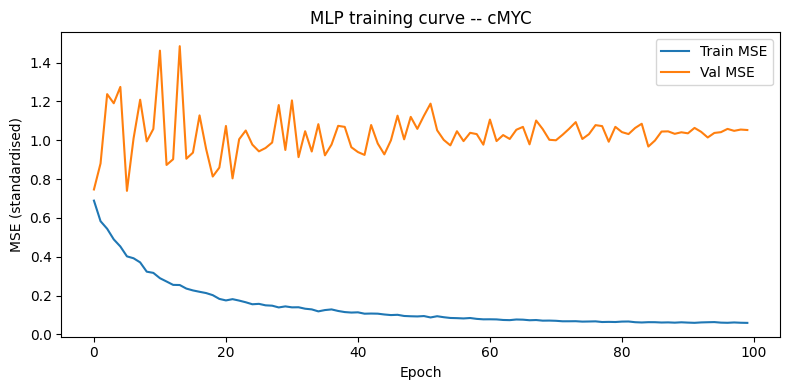

In [77]:
if tl_cmyc is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(tl_cmyc, label='Train MSE')
    ax.plot(vl_cmyc, label='Val MSE')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE (standardised)')
    ax.set_title('MLP training curve -- cMYC')
    ax.legend()
    plt.tight_layout()
    plt.savefig('output/q3a_training_curve.png', dpi=150)
    plt.show()
else:
    print('Model loaded from cache -- training history not available.')

#### (ii) Test-set Evaluation (Specimen D1)

,Value
Metric,
RMSE,1.0260
Pearson r,0.6748
Spearman r,0.6535
R²,0.2323


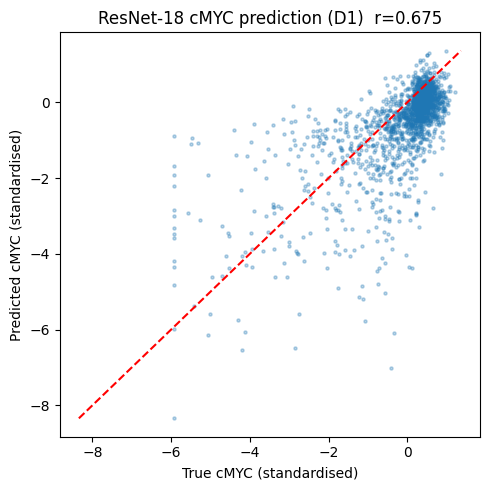

In [78]:
# evaluate on D1 test set
preds_cmyc = predict_mlp(model_cmyc, X_feat_test).ravel()
true_cmyc  = y_test_cmyc

rmse_cmyc      = np.sqrt(mean_squared_error(true_cmyc, preds_cmyc))
r_cmyc,    _   = stats.pearsonr(true_cmyc, preds_cmyc)
rho_cmyc,  _   = stats.spearmanr(true_cmyc, preds_cmyc)
r2_cmyc        = r2_score(true_cmyc, preds_cmyc)

metrics_df = pd.DataFrame({
    'Metric': ['RMSE', 'Pearson r', 'Spearman r', 'R²'],
    'Value':  [round(rmse_cmyc, 4), round(r_cmyc, 4), round(rho_cmyc, 4), round(r2_cmyc, 4)]
}).set_index('Metric')
display(metrics_df)

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(true_cmyc, preds_cmyc, alpha=0.3, s=5)
lims = [min(true_cmyc.min(), preds_cmyc.min()),
        max(true_cmyc.max(), preds_cmyc.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('True cMYC (standardised)')
ax.set_ylabel('Predicted cMYC (standardised)')
ax.set_title(f'ResNet-18 cMYC prediction (D1)  r={r_cmyc:.3f}')
plt.tight_layout()
plt.savefig('output/q3a_scatter.png', dpi=150)
plt.show()

#### Interpretation

The model achieves a Pearson correlation of 0.6748 and a Spearman correlation of 0.6535 on the held-out specimen D1, with RMSE=1.0260 and R²=0.232. These results indicate that the model captures a meaningful relationship between image appearance and cMYC expression, explaining approximately 23% of the variance in the test set.

The training curve shows a clear overfitting pattern. Training MSE decreases steadily from 0.70 to around 0.06 over 100 epochs, while validation MSE oscillates around 1.0 throughout without any consistent downward trend. The gap between the two curves is large, indicating that the model memorises the training data rather than learning features that generalise to the test specimen.

The most likely cause is cross-specimen distribution shift. The model is trained on specimens A1, B1 and C1, and tested on D1. Each specimen can differ in staining intensity, tissue preparation and overall image appearance, so patterns learned from one set of specimens may not transfer cleanly to a new one. This kind of domain gap is a fundamental challenge in spatial transcriptomics prediction and is not fully addressed by regularisation alone.

Despite the overfitting in training, the test Pearson of 0.6748 is a reasonable result. This is largely because the frozen ResNet-18 backbone produces features that already carry generalised visual information from ImageNet pretraining, so even a head that overfits on training labels can still rank spots reasonably well at test time. The scatter plot confirms a positive trend between predicted and true values, though with spread around the identity line.

### (b) Multi-Target Prediction: All 38 Proteins

The same architecture is extended to predict all 38 proteins simultaneously. The MLP output dimension is changed from 1 to 38, and each output is independently z-scored using training-fold statistics. Performance is measured with **leave-one-specimen-out cross-validation (GroupKFold, 4 folds)** to give an unbiased estimate of generalisation to a new specimen.

In [70]:
protein_cols = protein_names
all_ids      = df.index.tolist()
all_groups   = df['specimen_id'].tolist()
gkf          = GroupKFold(n_splits=4)

# full feature matrix aligned with df row order
X_feat_all = np.array([feat_dict[i] for i in all_ids], dtype=np.float32)

fold_results = []
fold_pbar = tqdm_nb(
    enumerate(gkf.split(np.arange(len(df)), groups=all_groups)),
    total=4, desc='CV folds', unit='fold'
)
for fold, (tr_idx, va_idx) in fold_pbar:
    fold_pbar.set_description(
        f'Fold {fold+1}/4 (train={len(tr_idx)}, val={len(va_idx)})'
    )

    X_tr_f = X_feat_all[tr_idx]
    X_va_f = X_feat_all[va_idx]

    # z-score proteins on training fold only
    scaler_prot = StandardScaler().fit(df[protein_cols].values[tr_idx])
    y_tr_f = scaler_prot.transform(
        df[protein_cols].values[tr_idx]
    ).astype(np.float32)
    y_va_f = scaler_prot.transform(
        df[protein_cols].values[va_idx]
    ).astype(np.float32)

    torch.manual_seed(RANDOM_SEED)
    fold_cache = f'output/cache_mlp_multi_fold{fold+1}.pt'
    m = FeatureMLP(in_dim=512, hidden=256, out_dim=len(protein_cols))
    m, _, _ = fit_mlp(m, X_tr_f, y_tr_f, X_va_f, y_va_f,
                      EPOCHS, LR, fold_cache)

    preds_f = predict_mlp(m, X_va_f)  # (N_va, 38)
    fold_dict = {}
    for pi, pname in enumerate(protein_cols):
        r_p,   _ = stats.pearsonr(y_va_f[:, pi],  preds_f[:, pi])
        rho_p, _ = stats.spearmanr(y_va_f[:, pi], preds_f[:, pi])
        rmse_p   = np.sqrt(mean_squared_error(y_va_f[:, pi], preds_f[:, pi]))
        r2_p     = r2_score(y_va_f[:, pi], preds_f[:, pi])
        fold_dict[pname] = (r_p, rho_p, rmse_p, r2_p)
    fold_results.append(fold_dict)

    mean_rho = np.mean([fold_dict[p][1] for p in protein_cols])
    fold_pbar.set_postfix(mean_spearman=f'{mean_rho:.4f}')
    del m

# average metrics across folds
metrics_rows = []
for pname in protein_cols:
    rs    = [fold_results[f][pname][0] for f in range(4)]
    rhos  = [fold_results[f][pname][1] for f in range(4)]
    rmses = [fold_results[f][pname][2] for f in range(4)]
    r2s   = [fold_results[f][pname][3] for f in range(4)]
    metrics_rows.append({
        'protein':        pname,
        'mean_pearson':   np.mean(rs),    'std_pearson':   np.std(rs),
        'mean_spearman':  np.mean(rhos),  'std_spearman':  np.std(rhos),
        'mean_rmse':      np.mean(rmses), 'std_rmse':      np.std(rmses),
        'mean_r2':        np.mean(r2s),   'std_r2':        np.std(r2s),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values('mean_spearman', ascending=False)
n_above_07 = (metrics_df['mean_spearman'] > 0.7).sum()
print(metrics_df.to_string(index=False))
print(f'\nProteins with mean Spearman > 0.7: {n_above_07}')
metrics_df.to_csv('output/q3b_protein_metrics.csv', index=False)

CV folds:   0%|          | 0/4 [00:00<?, ?fold/s]

Loading cached model from output/cache_mlp_multi_fold1.pt
Loading cached model from output/cache_mlp_multi_fold2.pt
Loading cached model from output/cache_mlp_multi_fold3.pt
Loading cached model from output/cache_mlp_multi_fold4.pt
protein  mean_pearson  std_pearson  mean_spearman  std_spearman  mean_rmse  std_rmse   mean_r2   std_r2
 NESTIN      0.521640     0.036369       0.544856      0.136228   0.855325  0.212744  0.112038 0.171342
   CDK4      0.544949     0.088067       0.502602      0.174819   0.870320  0.081324  0.275524 0.103298
    MET      0.436873     0.060619       0.382442      0.081198   0.945105  0.172225  0.049706 0.107379
 PDGFRa      0.442274     0.089748       0.355569      0.091631   0.923520  0.099376  0.112621 0.040941
   pERK      0.311554     0.099251       0.331950      0.065079   1.028293  0.090645 -0.060019 0.223250
   MHCI      0.377093     0.124035       0.319435      0.160979   1.002334  0.125079  0.009010 0.208032
  CD11b      0.320584     0.205730      

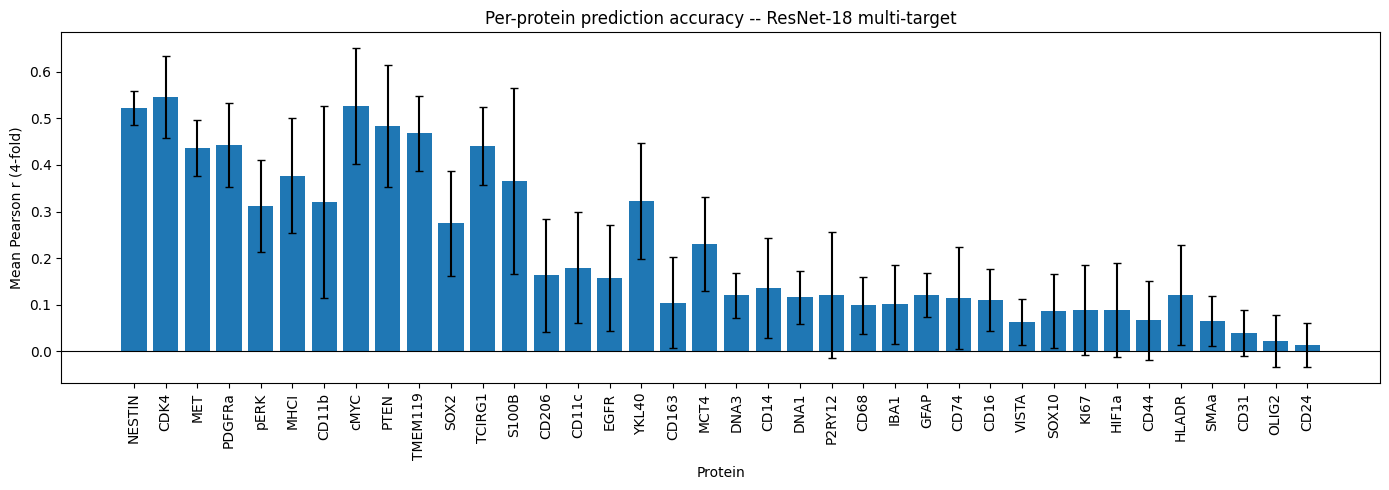

In [71]:
# bar chart of per-protein Pearson correlations
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(metrics_df['protein'], metrics_df['mean_pearson'],
       yerr=metrics_df['std_pearson'], capsize=3)
ax.axhline(0, color='k', linewidth=0.8)
ax.set_xlabel('Protein')
ax.set_ylabel('Mean Pearson r (4-fold)')
ax.set_title('Per-protein prediction accuracy -- ResNet-18 multi-target')
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig('output/q3b_protein_pearson.png', dpi=150)
plt.show()

#### Interpretation

Prediction quality varies a lot across the 38 proteins. NESTIN and CDK4 have the highest mean Spearman correlations at 0.545 and 0.503, which means the model can rank spots reasonably well for these two proteins. MET and PDGFRa also show moderate performance around 0.35 to 0.38. For most proteins, the mean Spearman is below 0.3, and no protein reaches the 0.7 threshold, so the count above 0.7 is 0. This suggests that some proteins have expression patterns that are more visible in the image while others are driven by molecular processes that simply cannot be seen from the tissue appearance.

The standard deviation across folds is quite high for several proteins, such as CD11b (std=0.223) and cMYC (std=0.215). This means the model works well on some specimen transitions but not others, which points to inter-specimen variation being a real problem. A few proteins also have negative mean R², meaning the model does worse than just predicting the mean value, so it has not learned anything useful for those targets. Overall, getting 0 proteins above the Spearman 0.7 threshold shows that predicting all 38 proteins from image features alone is a hard task, especially under leave-one-specimen-out evaluation where the test specimen is always unseen during training.

### (c) Improving prediction and testing independence

#### (i) Adding Spatial Coordinates as Auxiliary Input

The spatial coordinates (x, y) of each spot are appended to the 512-dimensional ResNet feature vector, giving a 514-dimensional input. A second MLP (`FeatureMLPWithCoords`) is trained on this augmented input and compared against the baseline (image features only). Coordinates are z-scored using training-set statistics to prevent data leakage.

In [72]:
# derive x, y coordinates if not already in df
has_xy = ('x' in df.columns) and ('y' in df.columns)
if not has_xy:
    def _parse_xy(img_id):
        part = img_id.split('_', 1)[1]   # e.g. '40x30'
        col, row = part.split('x')
        return float(col), float(row)
    _coords = np.array([_parse_xy(i) for i in df.index], dtype=np.float32)
    df = df.copy()
    df['x'], df['y'] = _coords[:, 0], _coords[:, 1]
    train_df = df[df['specimen_id'].isin(['A1', 'B1', 'C1'])].copy()
    test_df  = df[df['specimen_id'] == 'D1'].copy()
    print('Parsed x/y from image_id.')

xy_train = train_df[['x', 'y']].values.astype(np.float32)
xy_test  = test_df[['x', 'y']].values.astype(np.float32)
scaler_xy = StandardScaler().fit(xy_train)
xy_train_n = scaler_xy.transform(xy_train)
xy_test_n  = scaler_xy.transform(xy_test)

# re-align feature matrices in case train_df/test_df were rebuilt
X_feat_train_c = np.array(
    [feat_dict[i] for i in train_df.index], dtype=np.float32
)
X_feat_test_c = np.array(
    [feat_dict[i] for i in test_df.index], dtype=np.float32
)

# augmented inputs: [512-dim ResNet features | 2-dim coords]
X_tr_c = np.concatenate([X_feat_train_c, xy_train_n], axis=1)  # (N_train, 514)
X_va_c = np.concatenate([X_feat_test_c,  xy_test_n],  axis=1)  # (N_test,  514)

torch.manual_seed(RANDOM_SEED)
cache_coords = 'output/cache_mlp_coords.pt'
model_coords = FeatureMLPWithCoords(feat_dim=512, coord_dim=2, out_dim=1)
model_coords, tl_c, vl_c = fit_mlp(
    model_coords,
    X_tr_c, y_train_cmyc,
    X_va_c, y_test_cmyc,
    EPOCHS, LR, cache_coords
)
print('Coord MLP ready.')

Parsed x/y from image_id.
Loading cached model from output/cache_mlp_coords.pt
Coord MLP ready.


Baseline (image only):  RMSE=1.0260  Pearson=0.6748  Spearman=0.6535  R2=0.232
With spatial coords:    RMSE=1.1093  Pearson=0.6604  Spearman=0.6525  R2=0.103


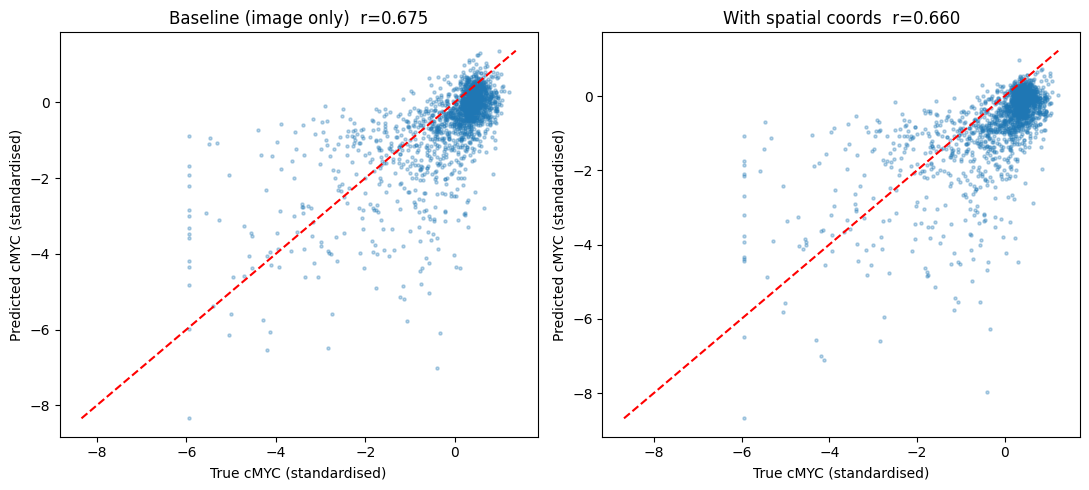

In [73]:
# evaluate coord model on D1
preds_coord = predict_mlp(model_coords, X_va_c).ravel()
true_coord  = y_test_cmyc

rmse_coord     = np.sqrt(mean_squared_error(true_coord, preds_coord))
r_coord,   _   = stats.pearsonr(true_coord, preds_coord)
rho_coord, _   = stats.spearmanr(true_coord, preds_coord)
r2_coord       = r2_score(true_coord, preds_coord)

print(f'Baseline (image only):  RMSE={rmse_cmyc:.4f}  '
      f'Pearson={r_cmyc:.4f}  Spearman={rho_cmyc:.4f}  R2={r2_cmyc:.3f}')
print(f'With spatial coords:    RMSE={rmse_coord:.4f}  '
      f'Pearson={r_coord:.4f}  Spearman={rho_coord:.4f}  R2={r2_coord:.3f}')

# side-by-side scatter comparison
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
for ax, preds, title in zip(
    axes,
    [preds_cmyc, preds_coord],
    ['Baseline (image only)', 'With spatial coords'],
):
    r_val, _ = stats.pearsonr(y_test_cmyc, preds)
    ax.scatter(y_test_cmyc, preds, alpha=0.3, s=5)
    lims = [min(y_test_cmyc.min(), preds.min()),
            max(y_test_cmyc.max(), preds.max())]
    ax.plot(lims, lims, 'r--')
    ax.set_xlabel('True cMYC (standardised)')
    ax.set_ylabel('Predicted cMYC (standardised)')
    ax.set_title(f'{title}  r={r_val:.3f}')
plt.tight_layout()
plt.savefig('output/q3c_scatter_comparison.png', dpi=150)
plt.show()

Spot location information could help prediction because protein expression often varies smoothly across tissue space. Nearby spots tend to share similar expression levels, so knowing where a spot is could help the model account for this spatial structure rather than treating each spot independently.

To test this, we appended the normalised (x, y) grid coordinates to the 512-dimensional image feature vector and retrained the model. The results show that adding coordinates does not improve performance on D1. Pearson drops from 0.6748 to 0.6604 and R² from 0.232 to 0.103. The reason is likely that each specimen has a different physical layout and tissue size, so coordinate values that are informative in the training specimens do not mean the same thing in D1. The model ends up learning position-expression associations that are specific to A1, B1 and C1 and fail to transfer.

A better approach would be to use coordinates relative to each specimen rather than absolute grid positions, or to use features derived from neighbouring spots such as average expression of nearby spots or a spatial lag term. These would encode local spatial context without depending on the absolute position within a particular specimen.

#### (ii) Protein Co-expression and Prediction Error Analysis

Proteins that are highly co-expressed might share visual features, making them easier to predict together.
This analysis examines whether proteins highly correlated with cMYC in the training set also tend to have lower prediction error in the multi-target model.

D1 is validation fold 3


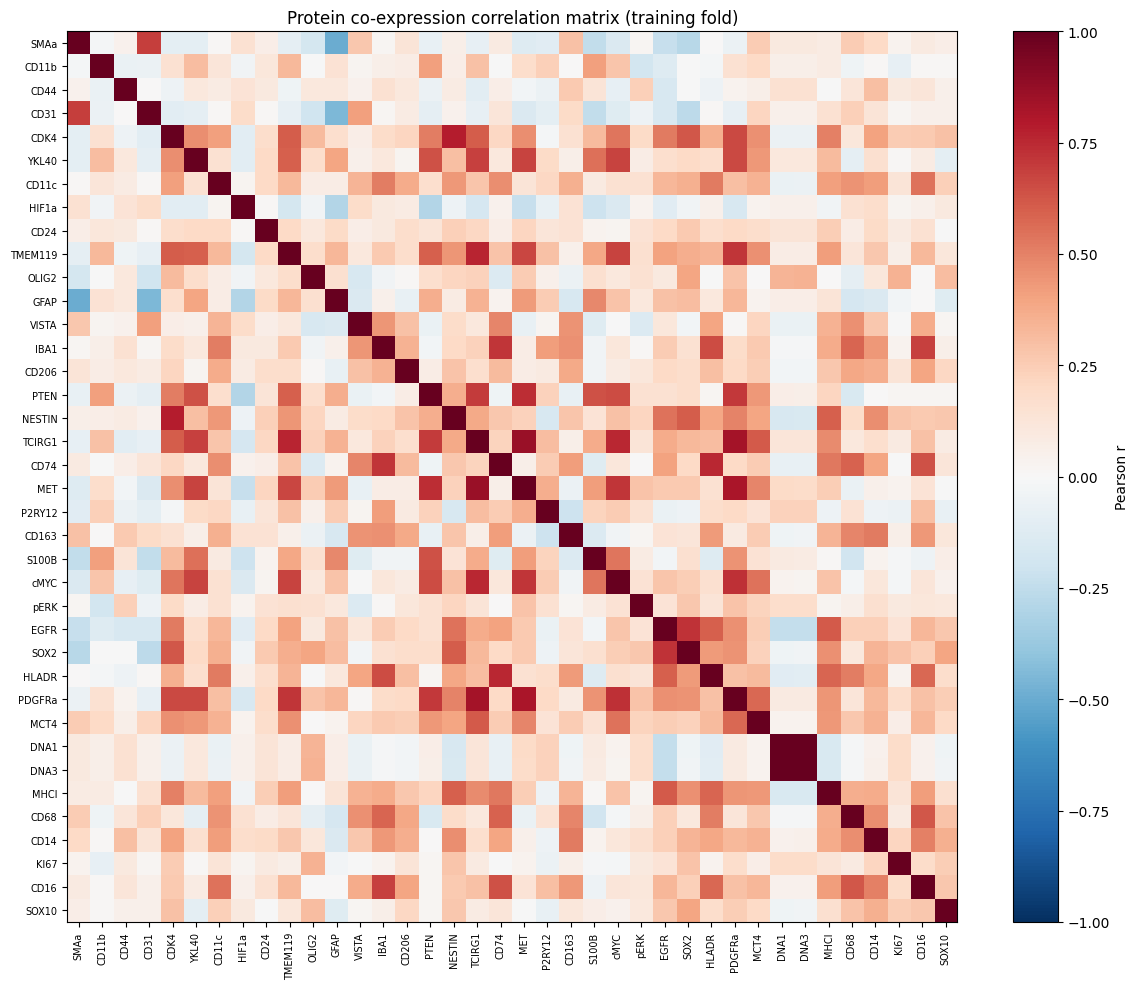

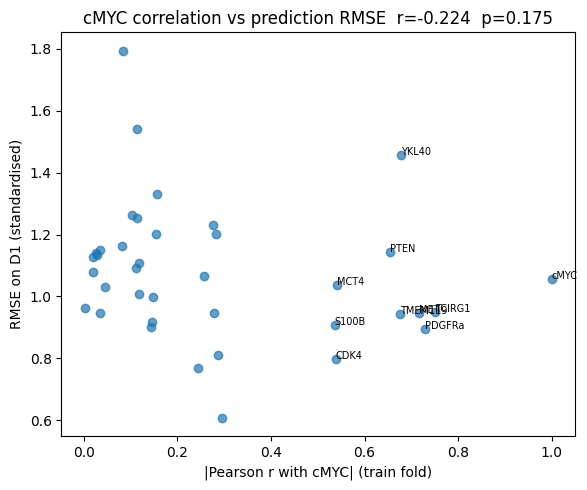

Pearson r (|corr with cMYC| vs RMSE): -0.2245  p=0.1755


In [74]:
# identify which fold corresponds to D1
spec_list    = df['specimen_id'].tolist()
all_ids_full = df.index.tolist()
fold_assigns = list(gkf.split(np.arange(len(df)), groups=spec_list))

d1_fold = next(
    fi for fi, (_, va_i) in enumerate(fold_assigns)
    if 'D1' in {spec_list[i] for i in va_i}
)
d1_tr_idx, d1_va_idx = fold_assigns[d1_fold]
print(f'D1 is validation fold {d1_fold + 1}')

# reload D1 fold model
fold_cache_d1 = f'output/cache_mlp_multi_fold{d1_fold + 1}.pt'
m_d1 = FeatureMLP(in_dim=512, hidden=256, out_dim=len(protein_cols))
m_d1.load_state_dict(torch.load(fold_cache_d1, map_location=device))
m_d1.to(device)

# predictions on D1
X_d1 = X_feat_all[d1_va_idx]
scaler_prot_d1 = StandardScaler().fit(df[protein_cols].values[d1_tr_idx])
y_d1_true = scaler_prot_d1.transform(
    df[protein_cols].values[d1_va_idx]
).astype(np.float32)
y_d1_pred = predict_mlp(m_d1, X_d1)

# per-protein RMSE on D1
d1_rmse = {
    pname: np.sqrt(mean_squared_error(y_d1_true[:, pi], y_d1_pred[:, pi]))
    for pi, pname in enumerate(protein_cols)
}

# protein co-expression correlation matrix (training fold)
train_prot  = df[protein_cols].values[d1_tr_idx]
corr_mat    = np.corrcoef(train_prot.T)   # (38, 38)
cmyc_ci     = protein_cols.index('cMYC')
cmyc_corrs  = corr_mat[cmyc_ci]

# heatmap
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr_mat, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
ax.set_xticks(range(len(protein_cols)))
ax.set_yticks(range(len(protein_cols)))
ax.set_xticklabels(protein_cols, rotation=90, fontsize=7)
ax.set_yticklabels(protein_cols, fontsize=7)
plt.colorbar(im, ax=ax, label='Pearson r')
ax.set_title('Protein co-expression correlation matrix (training fold)')
plt.tight_layout()
plt.savefig('output/q3c_protein_corr_heatmap.png', dpi=150)
plt.show()

# scatter: |corr with cMYC| vs prediction RMSE
corr_vals = [cmyc_corrs[protein_cols.index(p)] for p in protein_cols]
rmse_vals = [d1_rmse[p] for p in protein_cols]
r_cr, p_cr = stats.pearsonr(np.abs(corr_vals), rmse_vals)

fig2, ax2 = plt.subplots(figsize=(6, 5))
ax2.scatter(np.abs(corr_vals), rmse_vals, alpha=0.7)
for p, cx, ry in zip(protein_cols, np.abs(corr_vals), rmse_vals):
    if cx > 0.4 or ry < 0.6:
        ax2.annotate(p, (cx, ry), fontsize=7)
ax2.set_xlabel('|Pearson r with cMYC| (train fold)')
ax2.set_ylabel('RMSE on D1 (standardised)')
ax2.set_title(f'cMYC correlation vs prediction RMSE  r={r_cr:.3f}  p={p_cr:.3f}')
plt.tight_layout()
plt.savefig('output/q3c_corr_vs_rmse.png', dpi=150)
plt.show()

print(f'Pearson r (|corr with cMYC| vs RMSE): {r_cr:.4f}  p={p_cr:.4f}')

To check whether the model is predicting cMYC specifically rather than picking up signals from correlated proteins, we look at whether proteins that are more correlated with cMYC also tend to have lower prediction RMSE. If the model were using shared visual signals from correlated proteins to predict cMYC indirectly, we would expect more correlated proteins to be easier to predict.

The result is r = -0.2245, p = 0.1755. This is not statistically significant, so there is no clear evidence that the model relies on co-expressed proteins to make its cMYC predictions. This is tentative evidence that the model is responding to cMYC-relevant visual features rather than exploiting co-expression structure.

A more rigorous check would be to compare the prediction vectors from the cMYC model and from models trained on other proteins. If the vectors are highly correlated, that would suggest the model is capturing a shared signal. If the model were found not to be specific, one option would be to train the model using residuals after removing the component explained by the most correlated proteins, such as CDK4, so that only the cMYC-specific variation remains as the training target.